In [16]:
import sys
import subprocess
try:
    import paramiko
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'paramiko'])
    import paramiko
import sys
import subprocess
try:
    import paramiko
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'paramiko'])
    import paramiko
from config import host, username, password

client = paramiko.SSHClient()
client.set_missing_host_key_policy(paramiko.AutoAddPolicy())

try:
    client.connect(host, username=username, password=password)

    # Search for the file
    stdin, stdout, stderr = client.exec_command("find ~ -name 'sandwich_script.r' 2>/dev/null")
    result = stdout.read().decode().strip()
    stdin.close()
    stdout.close()
    stderr.close()
    
    print("Found at:")
    print(result)

    # Run the R script with a user-writable library directory
    if result:
        script_path = result.split('\n')[0]  # Get the first result if multiple found
        print(f"\nRunning script: {script_path}")
        
        # Create user R library directory if it doesn't exist and set R_LIBS_USER
        command = f"mkdir -p ~/R/library && export R_LIBS_USER=~/R/library && Rscript {script_path}"
        stdin, stdout, stderr = client.exec_command(command)
        
        # Capture output
        output = stdout.read().decode()
        error = stderr.read().decode()
        
        # Close all streams
        stdin.close()
        stdout.close()
        stderr.close()
        
        print("Script output:")
        print(output)
        
        if error:
            print("Errors/Warnings:")
            print(error)
    else:
        print("Script not found!")

finally:
    # Always close the connection
    client.close()


Found at:
/home/NETID/emd5/sandwich_script.r

Running script: /home/NETID/emd5/sandwich_script.r
Script output:

Replacing 4 sentinel 999 values with NA in basic_plus_clinical_analysis_df column scl.avg.global.score 

Replacing 23 sentinel 999 values with NA in basic_plus_clinical_analysis_df column phq9.total 

Replacing 4 sentinel 999 values with NA in basic_plus_clinical_sdh_analysis_df column scl.avg.global.score 

Replacing 23 sentinel 999 values with NA in basic_plus_clinical_sdh_analysis_df column phq9.total 

Replacing 4 sentinel 999 values with NA in location_encoded_df column scl.avg.global.score 

Replacing 23 sentinel 999 values with NA in location_encoded_df column phq9.total 

Detected aliased variables in location_encoded_df (iteration 1 ): gender_4.0, SDS_Total, sexuality_4.0, PrimaryRUCA___MISSING__ 

Dropped aliased variables from location_encoded_df : gender_4.0, SDS_Total, sexuality_4.0, PrimaryRUCA___MISSING__ 

Checking for aliased (collinear) coefficients in loca

In [17]:
import os

# Print all files in the directory
data_dir = "/edata/obdw/sandwich_analysis_data/"
# print("Files in directory:")
# for f in os.listdir(data_dir):
#     print(f)

Note: you may need to restart the kernel to use updated packages.
CSV files in directory:
X_basic_plus_clin_sdh_with_location.csv
mixed_model4_wer_random_slopes.csv
basic_plus_clinical_analysis_wer_coeftest.csv
basic_plus_analysis_wer_coeftest.csv
basic_plus_clinical_sdh_analysis.csv
python_vs_r_stratified_wer_comparison_summary.csv
regression_stratified_Y_WER.csv
basic_plus_clinical_sdh_analysis_coh_coeftest.csv
vif_model3.csv
regression_stratified_log_wer.csv
regression_stratified_Y_COH.csv
python_vs_r_stratified_wer_comparison_full.csv
location_encoded_analysis_coh_coeftest.csv
mixed_model2_wer_with_stratification.csv
wer_by_race_descriptives.csv
basic_analysis_coh_coeftest.csv
basic_plus_analysis_coh_coeftest.csv
basic_plus_clinical_analysis_coh_coeftest.csv
basic_plus_clinical_analysis.csv
mixed_models_comparison.csv
X_basic_plus_clin_sdh_location_encoded.csv
regression_stratified_sentCoherenceSentBertCumulativeCentroid.csv
wer_demographic_tests_with_correction.csv
basic_plus_anal

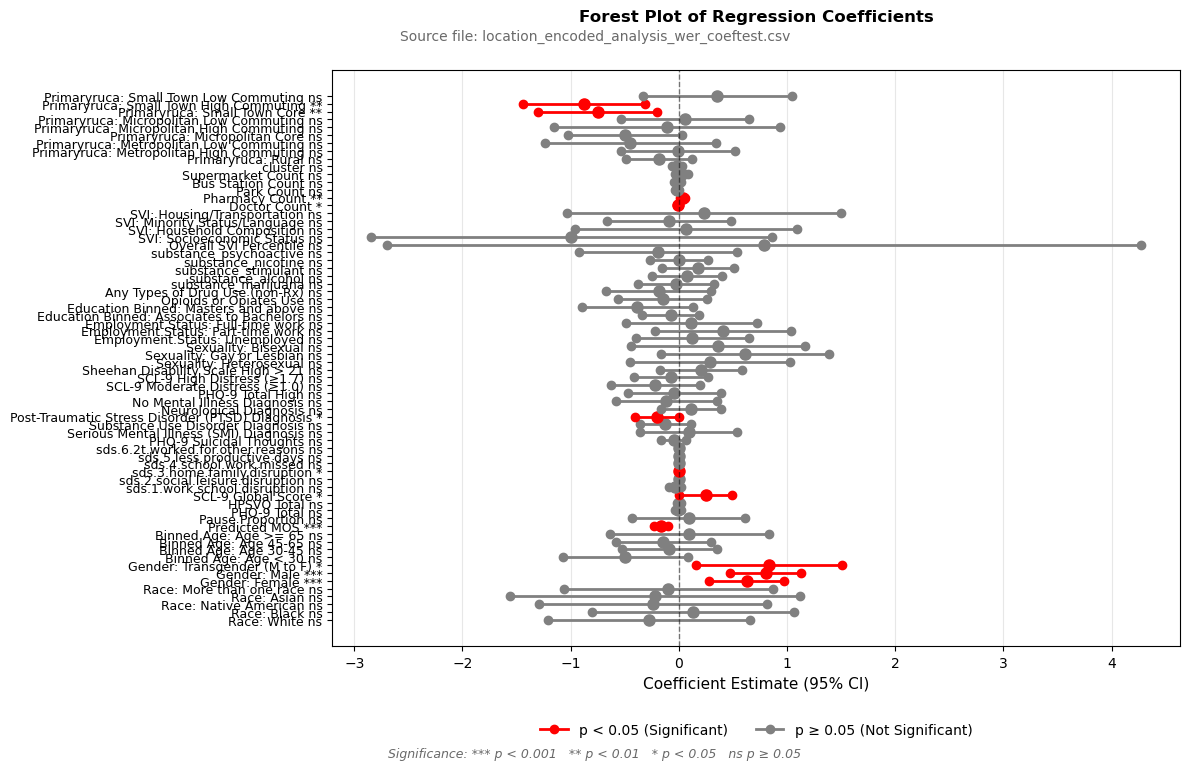

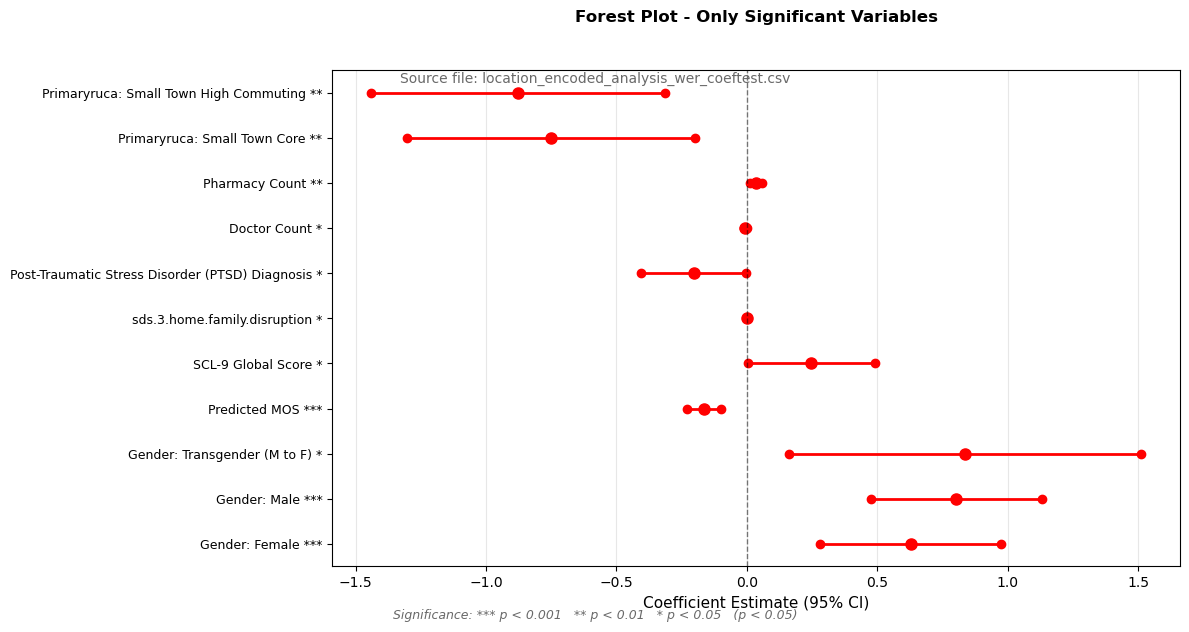

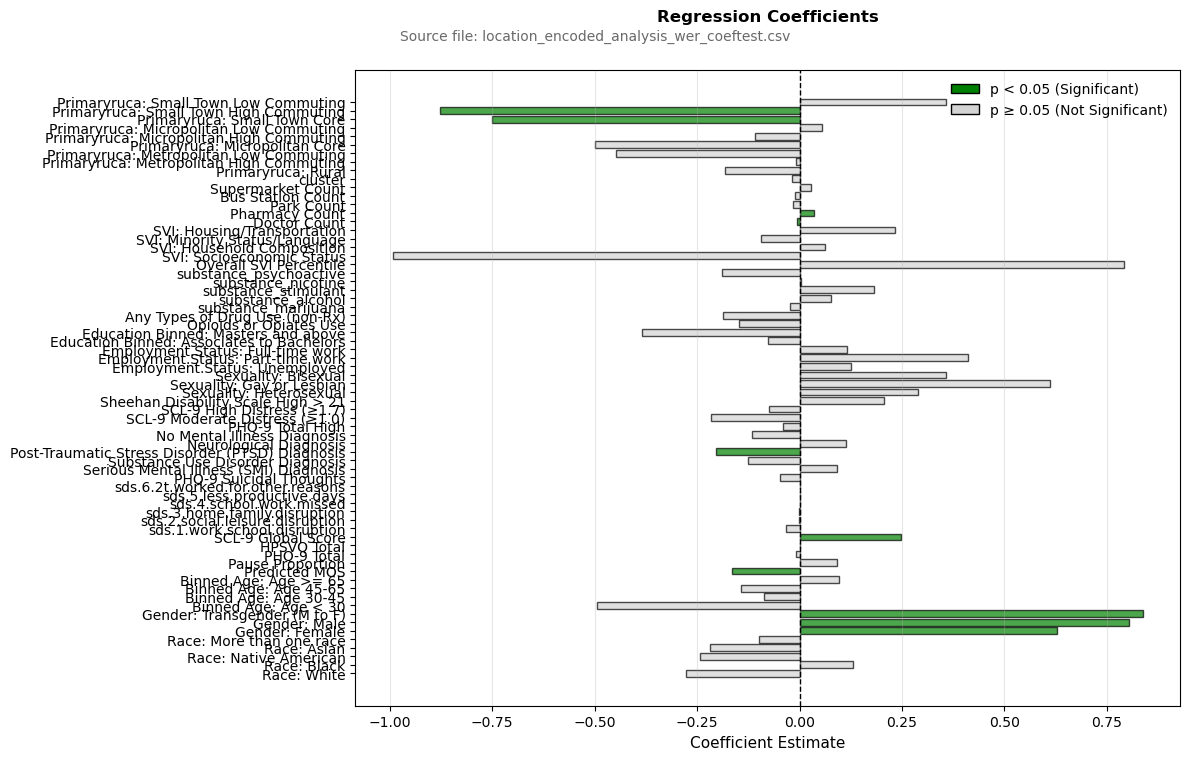


Processing file: location_stratified_analysis_wer_coeftest.csv


Summary Table:
                                                                                   Variable_Decoded  Estimate  Std_Error       p_value Significance Count
(Intercept)                                                                               Intercept  3.729544   0.857399  1.411526e-05          ***  None
pid                                                                                  Participant ID  0.000094   0.000060  1.192173e-01           ns  None
race_1.0                                                                                Race: White -0.179582   0.400807  6.541521e-01           ns  None
race_2.0                                                                                Race: Black  0.245694   0.414179  5.530909e-01           ns  None
race_4.0                                                                      Race: Native American  0.009126   0.438699  9.834052e-01           ns  

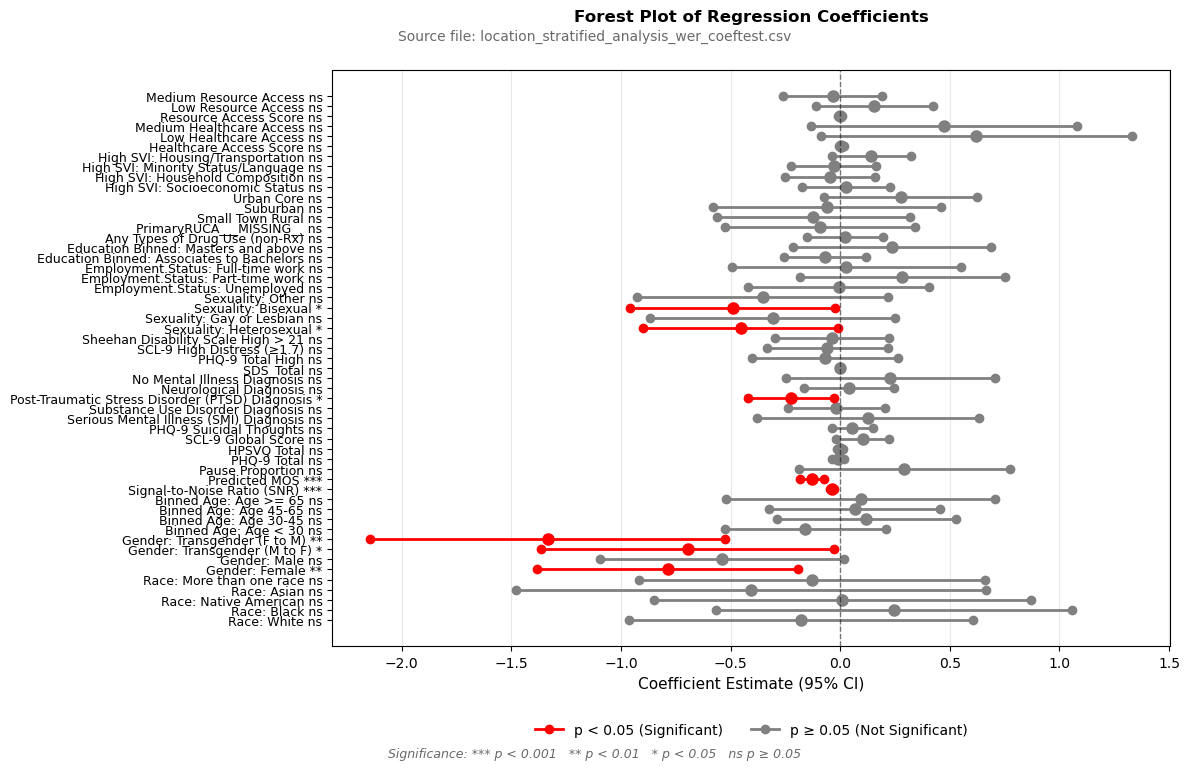

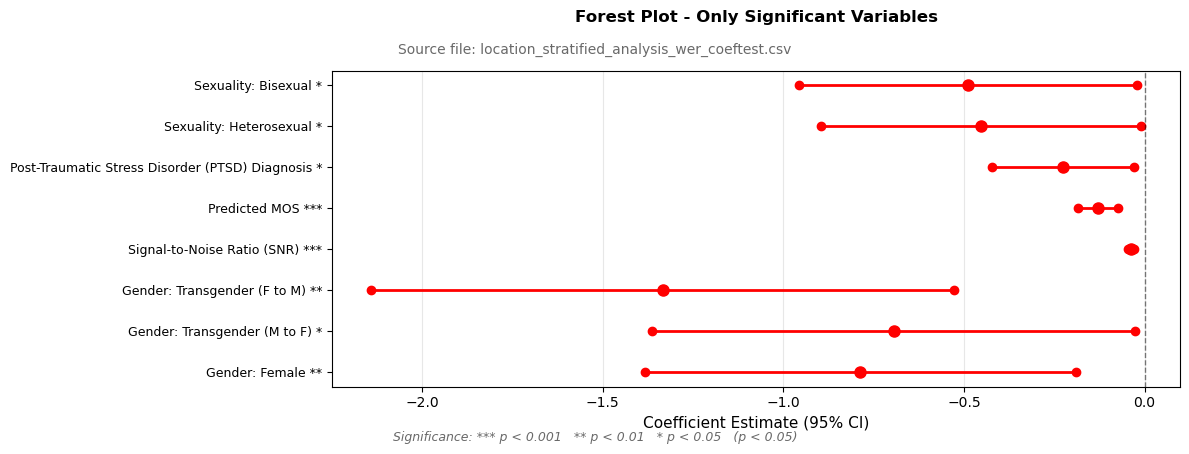

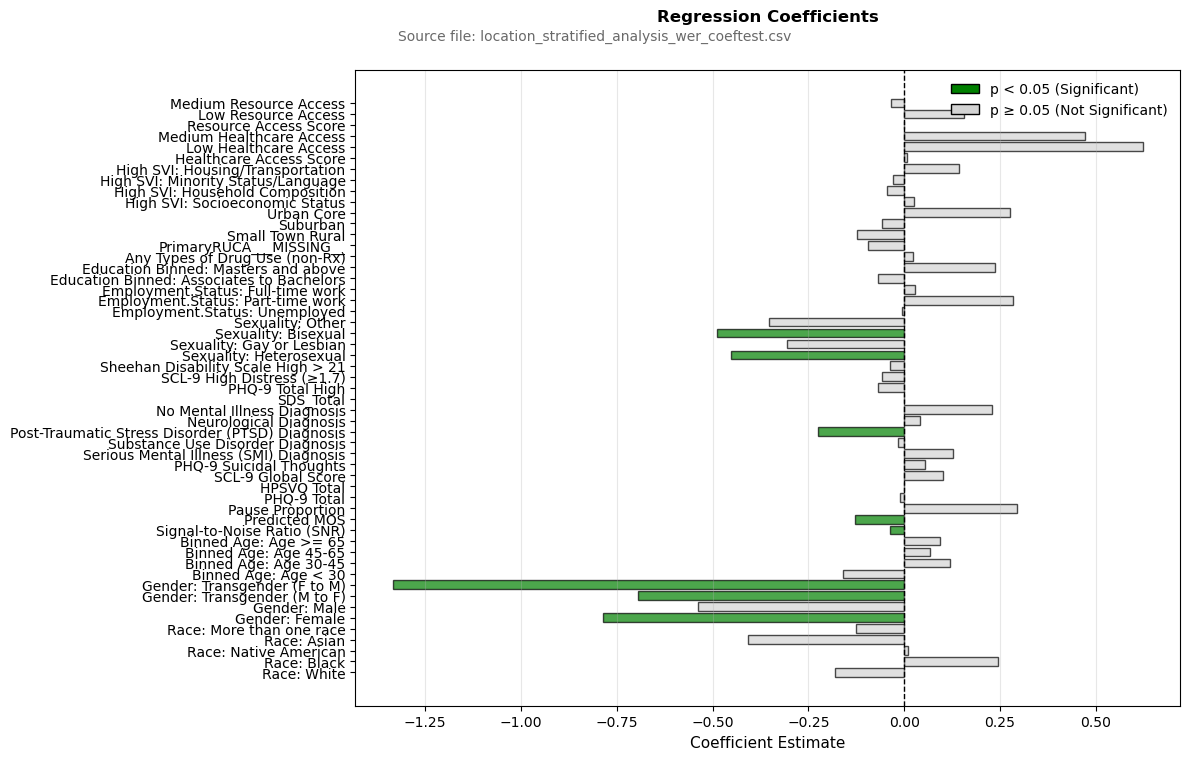


All coeftest files processed!


In [18]:
# Install required packages
%pip install pandas matplotlib numpy paramiko

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import paramiko
import os
import sys
sys.path.insert(0, "/home/NETID/emd5")
from avh_utils import decode_variable_name


# Mapping of coeftest files to their original data files
coeftest_to_data_mapping = {
    'basic_analysis_coeftest.csv': 'basic_analysis.csv',
    'basic_plus_analysis_coeftest.csv': 'basic_plus_analysis.csv',
    'basic_plus_clinical_analysis_coeftest.csv': 'basic_plus_clinical_analysis.csv',
    'basic_plus_clinical_sdh_analysis_coeftest.csv': 'basic_plus_clinical_sdh_analysis.csv',
    'X_basic_plus_clin_sdh_location_encoded_coeftest.csv': 'X_basic_plus_clin_sdh_location_encoded.csv'
}

# Mapping of coeftest files to their variable counts files
coeftest_to_counts_mapping = {
    'location_encoded_analysis_coh_coeftest.csv': 'X_location_encoded_variable_counts.csv',
    'X_basic_plus_clin_sdh_location_encoded_coeftest.csv': 'X_location_encoded_variable_counts.csv'
}

def get_variable_counts(var_name, counts_df=None):
    """
    Get counts for a variable from the variable counts dataframe.
    If counts_df is provided, look up the variable name and return the count.
    """
    var_name_str = str(var_name)
    
    # Handle intercept and special cases
    if var_name_str in ['(Intercept)', 'pid']:
        return None
    
    # If no counts dataframe provided, return None
    if counts_df is None:
        return None
    
    # Look up the variable in the counts dataframe
    matching_rows = counts_df[counts_df['Variable'] == var_name_str]
    if not matching_rows.empty:
        # Return the count from the 'Count' column
        count_col = 'Count' if 'Count' in counts_df.columns else 'Non-Null_Count'
        return int(matching_rows.iloc[0][count_col])
    
    return None


# Directory containing CSV files
data_dir = "/edata/obdw/sandwich_analysis_data/"

# Create output directory if it doesn't exist
output_dir = "output_graphs"
os.makedirs(output_dir, exist_ok=True)

# List all CSV files in the directory
csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
print("CSV files in directory:")
for f in csv_files:
    print(f)

# Loop through each coeftest CSV file and generate graphs
#coeftest_files = [f for f in csv_files if f.endswith('_coeftest.csv')]
#ToDo: Delete this, just for temporary processing faster
coeftest_files = [f for f in csv_files if f.endswith('_stratified_analysis_wer_coeftest.csv') or f.endswith('_encoded_analysis_wer_coeftest.csv')]


for csv_filename in coeftest_files:
    csv_path = os.path.join(data_dir, csv_filename)
    print(f"\n{'='*80}")
    print(f"Processing file: {csv_filename}")
    print(f"{'='*80}")
    
    try:
        df = pd.read_csv(csv_path, index_col=0)
    except Exception as e:
        print(f"Could not load {csv_filename}: {e}")
        continue

    # Load the corresponding original data file if available
    original_data_df = None
    if csv_filename in coeftest_to_data_mapping:
        original_data_file = coeftest_to_data_mapping[csv_filename]
        original_data_path = os.path.join(data_dir, original_data_file)
        try:
            original_data_df = pd.read_csv(original_data_path, index_col=0)
            print(f"Loaded original data: {original_data_file} ({original_data_df.shape[0]} rows)")
        except Exception as e:
            print(f"Could not load original data file {original_data_file}: {e}")

    # Standardize column names if needed
    column_mapping = {
        'p.value': 'p_value',
        'Pr(>|t|)': 'p_value',
        'Std. Error': 'Std_Error',
        'Std..Error': 'Std_Error',
        't value': 't_value',
        't.value': 't_value'
    }
    rename_dict = {old: new for old, new in column_mapping.items() if old in df.columns}
    if rename_dict:
        df.rename(columns=rename_dict, inplace=True)

    # Calculate 95% confidence intervals if not already present
    if 'CI_lower' not in df.columns and 'Estimate' in df.columns:
        std_error_col = 'Std_Error' if 'Std_Error' in df.columns else 'Std. Error' if 'Std. Error' in df.columns else None
        if std_error_col:
            df['CI_lower'] = df['Estimate'] - 1.96 * df[std_error_col]
            df['CI_upper'] = df['Estimate'] + 1.96 * df[std_error_col]

    # Create significance categories
    # Robustly find a p-value column
    p_value_col = None
    if 'p_value' in df.columns:
        p_value_col = 'p_value'
    else:
        pval_candidates = [c for c in df.columns if isinstance(c, str) and ('p' in c.lower() or 'pr' in c.lower())]
        if len(pval_candidates) > 0:
            p_value_col = pval_candidates[0]
    if p_value_col:
        df['Significance'] = df[p_value_col].apply(lambda x: '***' if x < 0.001 else '**' if x < 0.01 else '*' if x < 0.05 else 'ns')
        df['p_value'] = df[p_value_col]  # Ensure p_value column exists for later use
    else:
        print(f"WARNING: Could not find p-value column in {csv_filename}!")

    # Add Variable column from index for easier reference
    if 'Variable' not in df.columns:
        df['Variable'] = df.index

    # # Add observation counts if original data is available
    if original_data_df is not None:
        df['Count'] = df['Variable'].apply(lambda x: get_variable_counts(original_data_df, x))
        print(f"\nVariable counts added from original data")
    else:
        df['Count'] = None
        print(f"\nWARNING: No original data file found, counts not available")

    # Decode variable names for plotting
    df['Variable_Decoded'] = df['Variable'].apply(decode_variable_name)

    # Print summary table with counts
    print(f"\nSummary Table:")
    summary_cols = ['Variable_Decoded', 'Estimate', 'Std_Error', 'p_value', 'Significance', 'Count']
    available_cols = [col for col in summary_cols if col in df.columns]
    print(df[available_cols].to_string())

    # --- Forest Plot: Estimates with 95% confidence intervals ---
    if 'Estimate' in df.columns and 'CI_lower' in df.columns and 'CI_upper' in df.columns:
        df_plot = df[~df['Variable'].isin(['(Intercept)', 'pid'])].copy()
        fig, ax = plt.subplots(figsize=(12, 8))
        for idx, row in df_plot.iterrows():
            color = 'red' if row.get('p_value', 1) < 0.05 else 'gray'
            ax.plot([row['CI_lower'], row['CI_upper']], [idx, idx], 'o-', color=color, linewidth=2, markersize=6)
            ax.plot(row['Estimate'], idx, 'o', color=color, markersize=8)
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
        ax.set_yticks(range(len(df_plot)))
        
        # Add counts to y-axis labels if available
        if 'Count' in df_plot.columns and df_plot['Count'].notna().any():
            ylabels = [f"{row['Variable_Decoded']} {row['Significance']} (n={int(row['Count'])})" if pd.notna(row['Count']) 
                      else f"{row['Variable_Decoded']} {row['Significance']}" 
                      for _, row in df_plot.iterrows()]
        else:
            ylabels = [f"{row['Variable_Decoded']} {row['Significance']}" for _, row in df_plot.iterrows()]
        
        ax.set_yticklabels(ylabels, fontsize=9)
        ax.set_xlabel('Coefficient Estimate (95% CI)', fontsize=11)
        ax.set_title('Forest Plot of Regression Coefficients', fontsize=12, fontweight='bold', pad=35, loc='center')
        plt.suptitle(f"Source file: {csv_filename}", fontsize=10, y=0.92, color='dimgray', ha='center')
        ax.grid(True, alpha=0.3, axis='x')
        red_patch = plt.Line2D([0], [0], color='red', marker='o', linestyle='-', linewidth=2, markersize=6, label='p < 0.05 (Significant)')
        gray_patch = plt.Line2D([0], [0], color='gray', marker='o', linestyle='-', linewidth=2, markersize=6, label='p ≥ 0.05 (Not Significant)')
        plt.legend(handles=[red_patch, gray_patch], loc='lower center', bbox_to_anchor=(0.5, -0.18), ncol=2, frameon=False, fontsize=10)

        # Add significance explanation text
        sig_text = "Significance: *** p < 0.001   ** p < 0.01   * p < 0.05   ns p ≥ 0.05"
        plt.figtext(0.5, 0.01, sig_text, ha='center', fontsize=9, style='italic', color='dimgray')
        
        plt.tight_layout()
        forest_path = os.path.join(output_dir, f"{csv_filename}_forest_plot.png")
        plt.savefig(forest_path, bbox_inches='tight', dpi=300)
        plt.show()


        # --- Forest Plot: Only Significant Variables ---
        if 'Estimate' in df.columns and 'CI_lower' in df.columns and 'CI_upper' in df.columns:
            # Filter for significant variables only, excluding intercept and pid
            df_plot = df[(df['p_value'] < 0.05) & ~df['Variable'].isin(['(Intercept)', 'pid'])].copy()
            
            # Only create plot if there are significant variables
            if len(df_plot) > 0:
                fig, ax = plt.subplots(figsize=(12, max(4, len(df_plot) * 0.6)))
                for idx, row in df_plot.iterrows():
                    color = 'red'  # All are significant, so all red
                    ax.plot([row['CI_lower'], row['CI_upper']], [idx, idx], 'o-', color=color, linewidth=2, markersize=6)
                    ax.plot(row['Estimate'], idx, 'o', color=color, markersize=8)
                ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
                ax.set_yticks(range(len(df_plot)))
                
                # Add counts to y-axis labels if available
                if 'Count' in df_plot.columns and df_plot['Count'].notna().any():
                    ylabels = [f"{row['Variable_Decoded']} {row['Significance']} (n={int(row['Count'])})" if pd.notna(row['Count']) 
                              else f"{row['Variable_Decoded']} {row['Significance']}" 
                              for _, row in df_plot.iterrows()]
                else:
                    ylabels = [f"{row['Variable_Decoded']} {row['Significance']}" for _, row in df_plot.iterrows()]
                
                ax.set_yticklabels(ylabels, fontsize=9)
                ax.set_xlabel('Coefficient Estimate (95% CI)', fontsize=11)
                ax.set_title('Forest Plot - Only Significant Variables', fontsize=12, fontweight='bold', pad=35, loc='center')
                plt.suptitle(f"Source file: {csv_filename}", fontsize=10, y=0.84, color='dimgray', ha='center')
                ax.grid(True, alpha=0.3, axis='x')
                
                # Add significance explanation text
                sig_text = "Significance: *** p < 0.001   ** p < 0.01   * p < 0.05   (p < 0.05)"
                plt.figtext(0.5, 0.01, sig_text, ha='center', fontsize=9, style='italic', color='dimgray')
                
                plt.tight_layout()
                forest_path = os.path.join(output_dir, f"{csv_filename}_forest_plot_significant.png")
                plt.savefig(forest_path, bbox_inches='tight', dpi=300)
                plt.show()
            else:
                print(f"No significant variables found in {csv_filename}")

        # --- Bar Plot: Simple coefficient visualization ---
        df_plot = df[~df['Variable'].isin(['(Intercept)', 'pid'])].copy()
        colors = ['green' if p < 0.05 else 'lightgray' for p in df_plot['p_value']]
        fig, ax = plt.subplots(figsize=(12, 8))
        plt.suptitle(f"Source file: {csv_filename}", fontsize=10, y=0.92, color='dimgray', ha='center')
        ax.barh(range(len(df_plot)), df_plot['Estimate'], color=colors, alpha=0.7, edgecolor='black')
        ax.set_yticks(range(len(df_plot)))
        ax.set_yticklabels(df_plot['Variable_Decoded'].values, fontsize=10)
        ax.set_xlabel('Coefficient Estimate', fontsize=11)
        ax.set_title('Regression Coefficients', fontsize=12, fontweight='bold', pad=35, loc='center')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, alpha=0.3, axis='x')
        from matplotlib.patches import Patch
        legend_handles = [
            Patch(facecolor='green', edgecolor='black', label='p < 0.05 (Significant)'),
            Patch(facecolor='lightgray', edgecolor='black', label='p ≥ 0.05 (Not Significant)')
        ]
        ax.legend(handles=legend_handles, loc='upper right', frameon=False, fontsize=10)
        
        plt.tight_layout()
        bar_path = os.path.join(output_dir, f"{csv_filename}_bar_plot.png")
        plt.savefig(bar_path, bbox_inches='tight', dpi=300)
        plt.show()

    else:
        print(f"Skipping {csv_filename}: required columns not found.")

print(f"\n{'='*80}")
print("All coeftest files processed!")
print(f"{'='*80}")

Loaded variable counts data: 76 variables

VARIABLE COUNTS SUMMARY
Total variables: 76
Variables with complete data (100%): 17
Variables with missing data: 59
Average non-null percentage: 50.48%


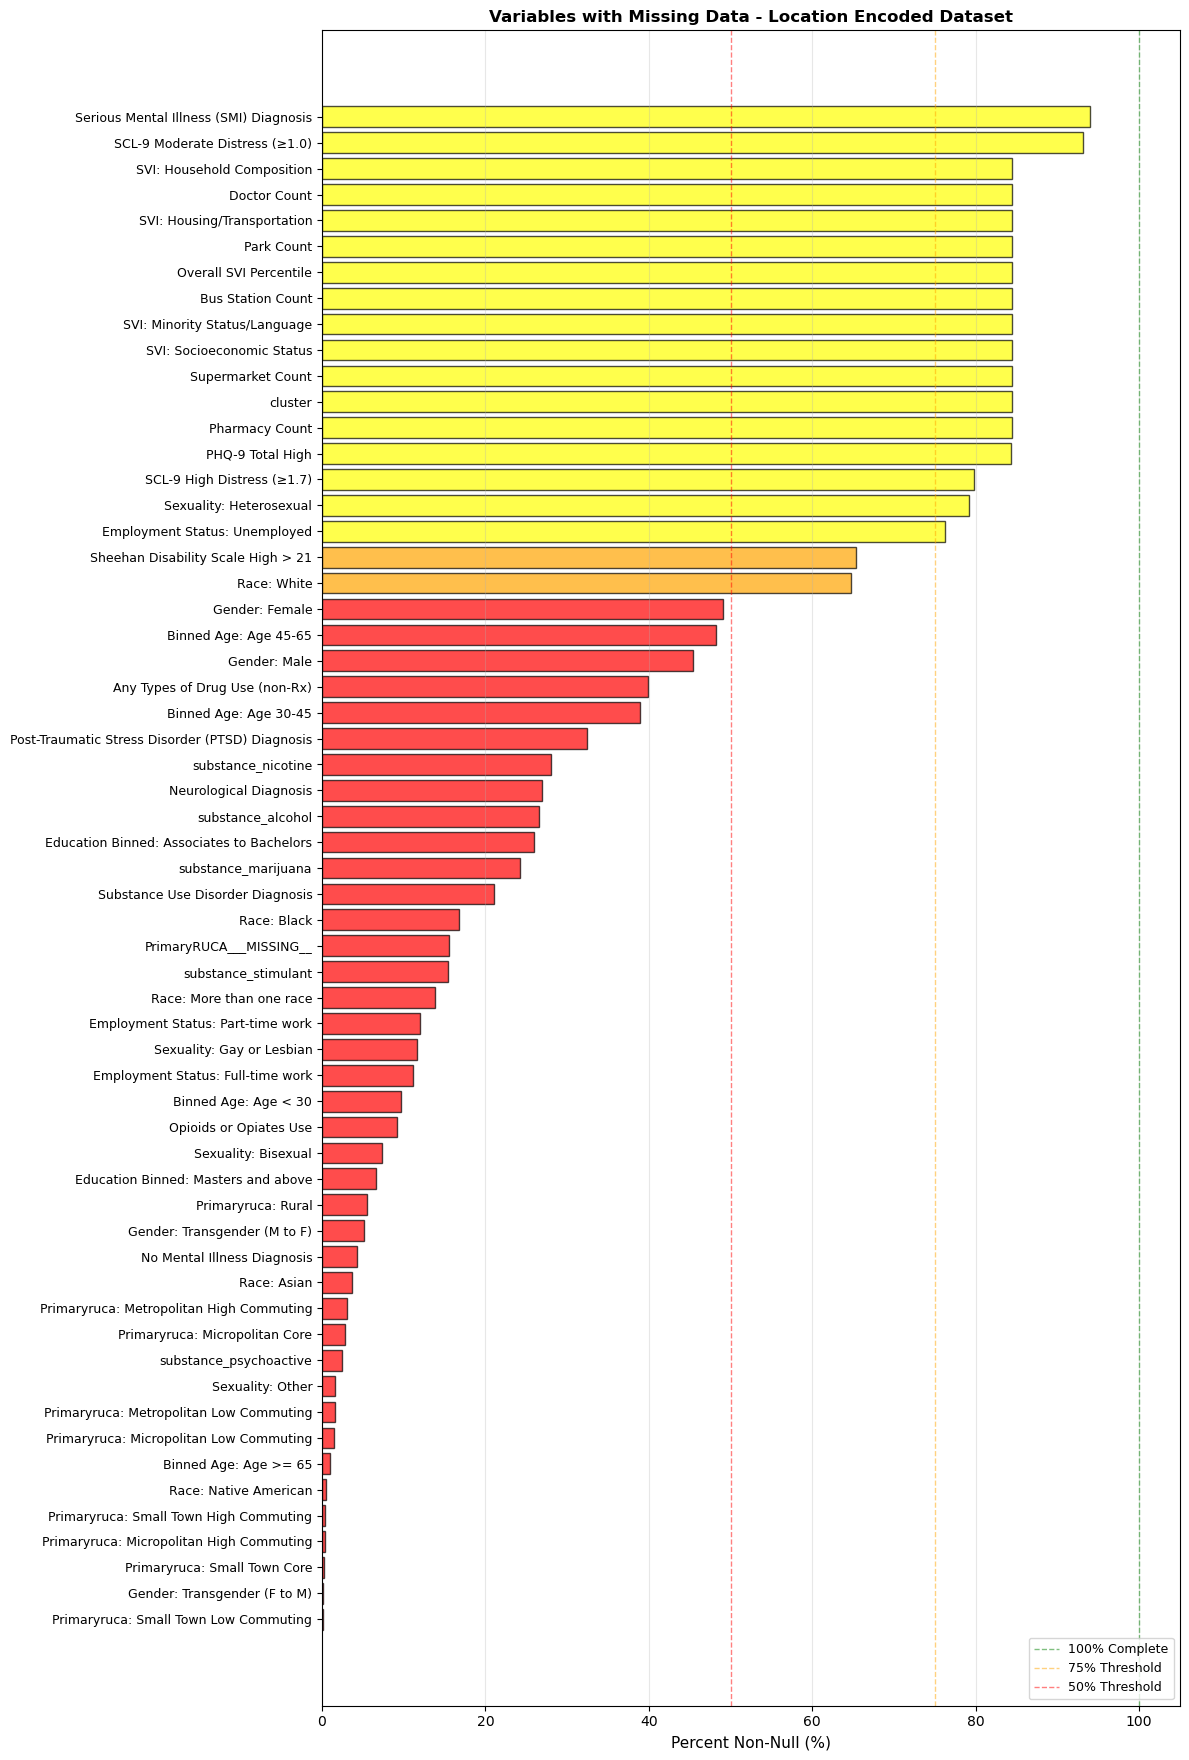


Variables with missing data:
               Variable  Count  Null_Count  Percent_Non-Null
        PrimaryRUCA_9.0      4           0              0.14
             gender_4.0      4           0              0.14
        PrimaryRUCA_7.0      7           0              0.24
        PrimaryRUCA_5.0     11           0              0.38
        PrimaryRUCA_8.0     12           0              0.42
               race_4.0     15           0              0.52
         binned_age_4.0     29           0              1.01
        PrimaryRUCA_6.0     41           0              1.43
        PrimaryRUCA_3.0     45           0              1.57
          sexuality_4.0     46           0              1.61
 substance_psychoactive     71           0              2.48
        PrimaryRUCA_4.0     81           0              2.83
        PrimaryRUCA_2.0     88           0              3.08
               race_5.0    105           0              3.67
          dx_group_none    123           0             

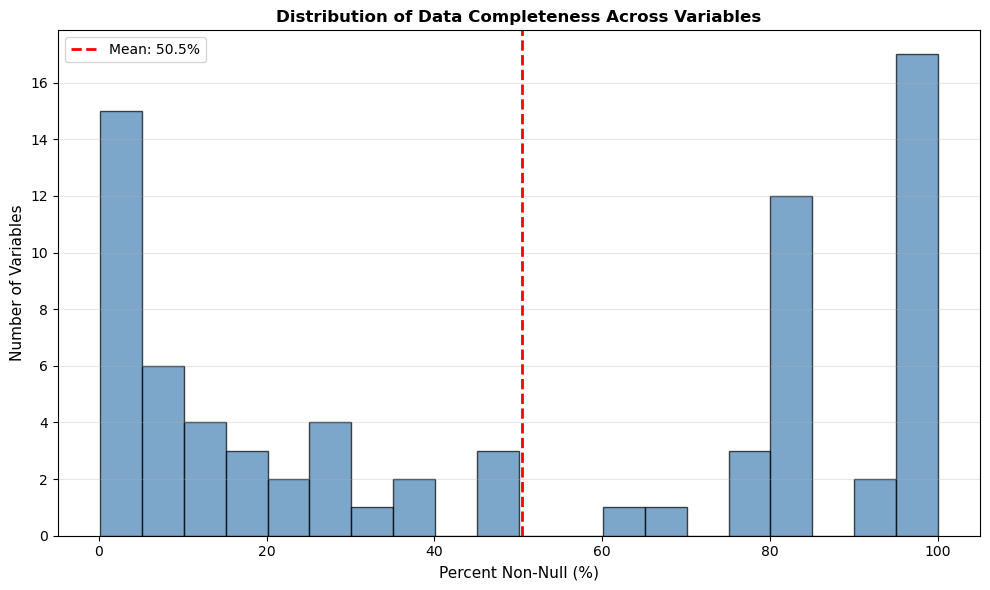

In [19]:
# Visualize Variable Counts from Location-Encoded Dataset
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the variable counts data
counts_path = "/edata/obdw/sandwich_analysis_data/X_location_encoded_variable_counts.csv"

try:
    counts_df = pd.read_csv(counts_path)
    print(f"Loaded variable counts data: {counts_df.shape[0]} variables")
    
    # Decode variable names for plotting
    counts_df['Variable_Decoded'] = counts_df['Variable'].apply(decode_variable_name)

    # Display summary statistics
    print(f"\n{'='*80}")
    print("VARIABLE COUNTS SUMMARY")
    print(f"{'='*80}")
    print(f"Total variables: {len(counts_df)}")
    print(f"Variables with complete data (100%): {(counts_df['Percent_Non-Null'] == 100).sum()}")
    print(f"Variables with missing data: {(counts_df['Percent_Non-Null'] < 100).sum()}")
    print(f"Average non-null percentage: {counts_df['Percent_Non-Null'].mean():.2f}%")
    
    # Filter to variables with missing data for visualization
    missing_data_df = counts_df[counts_df['Percent_Non-Null'] < 100].sort_values('Percent_Non-Null')
    
    if len(missing_data_df) > 0:
        # Create bar chart of variables with missing data
        fig, ax = plt.subplots(figsize=(12, max(6, len(missing_data_df) * 0.3)))
        
        colors = ['red' if p < 50 else 'orange' if p < 75 else 'yellow' for p in missing_data_df['Percent_Non-Null']]
        
        ax.barh(range(len(missing_data_df)), missing_data_df['Percent_Non-Null'], color=colors, alpha=0.7, edgecolor='black')
        ax.set_yticks(range(len(missing_data_df)))
        ax.set_yticklabels(missing_data_df['Variable_Decoded'].values, fontsize=9)
        ax.set_xlabel('Percent Non-Null (%)', fontsize=11)
        ax.set_title('Variables with Missing Data - Location Encoded Dataset', fontsize=12, fontweight='bold')
        ax.axvline(x=100, color='green', linestyle='--', linewidth=1, alpha=0.5, label='100% Complete')
        ax.axvline(x=75, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='75% Threshold')
        ax.axvline(x=50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% Threshold')
        ax.set_xlim(0, 105)
        ax.grid(True, alpha=0.3, axis='x')
        ax.legend(loc='lower right', frameon=True, fontsize=9)
        
        plt.tight_layout()
        plt.savefig('/edata/obdw/sandwich_analysis_data/variable_counts_missing_data.png', bbox_inches='tight', dpi=300)
        plt.show()
        
        print(f"\nVariables with missing data:")
        print(missing_data_df[['Variable', 'Count', 'Null_Count', 'Percent_Non-Null']].to_string(index=False))
    else:
        print("\nAll variables have complete data (no missing values)!")
    
    # Create histogram of non-null percentages
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(counts_df['Percent_Non-Null'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel('Percent Non-Null (%)', fontsize=11)
    ax.set_ylabel('Number of Variables', fontsize=11)
    ax.set_title('Distribution of Data Completeness Across Variables', fontsize=12, fontweight='bold')
    ax.axvline(x=counts_df['Percent_Non-Null'].mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {counts_df["Percent_Non-Null"].mean():.1f}%')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    plt.savefig('/edata/obdw/sandwich_analysis_data/variable_counts_distribution.png', bbox_inches='tight', dpi=300)
    plt.show()
    
except FileNotFoundError:
    print(f"File not found: {counts_path}")
    print("Please run the primary_data_collection_script.ipynb notebook first to generate this file.")
except Exception as e:
    print(f"Error loading or processing variable counts: {e}")


In [20]:
# Create a table showing which variables are present in each wer_coeftest.csv file
import pandas as pd
import os

# Directory containing CSV files
data_dir = "/edata/obdw/sandwich_analysis_data/"

# Find all files ending with 'wer_coeftest.csv'
wer_coeftest_files = [f for f in os.listdir(data_dir) if f.endswith('wer_coeftest.csv')]

print(f"Found {len(wer_coeftest_files)} wer_coeftest.csv files:")
for f in wer_coeftest_files:
    print(f"  - {f}")

# Dictionary to store variables for each file
file_variables = {}

# Collect all unique variables
all_variables = set()

for csv_filename in wer_coeftest_files:
    csv_path = os.path.join(data_dir, csv_filename)
    try:
        df = pd.read_csv(csv_path, index_col=0)
        # Get variables from index or Variable column
        if 'Variable' in df.columns:
            variables = df['Variable'].tolist()
        else:
            variables = df.index.tolist()
        file_variables[csv_filename] = set(variables)
        all_variables.update(variables)
    except Exception as e:
        print(f"Error loading {csv_filename}: {e}")
        file_variables[csv_filename] = set()

# Sort variables for consistent ordering
all_variables = sorted(all_variables)

# Create the presence/absence matrix
presence_matrix = pd.DataFrame(index=all_variables, columns=wer_coeftest_files)

for var in all_variables:
    for file in wer_coeftest_files:
        presence_matrix.loc[var, file] = 1 if var in file_variables[file] else 0

# Add decoded variable names as the first column
presence_matrix.insert(0, 'Decoded_Variable', presence_matrix.index.map(decode_variable_name))

# Display the table
print(f"\n{'='*100}")
print("VARIABLE PRESENCE MATRIX")
print(f"{'='*100}")
print("Rows: Variables, Columns: Files")
print("1 = Variable present in file, 0 = Variable absent")
print(f"Total variables: {len(all_variables)}")
print(f"Total files: {len(wer_coeftest_files)}")
print()

# Show the matrix with all rows and columns, and counts at the top
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(f"VARIABLE PRESENCE MATRIX: {presence_matrix.shape[0]} variables × {presence_matrix.shape[1] - 1} files")
print(f"Variables: {presence_matrix.shape[0]}")
print(f"Files: {presence_matrix.shape[1] - 1}")

display(presence_matrix)

Found 6 wer_coeftest.csv files:
  - basic_plus_clinical_analysis_wer_coeftest.csv
  - basic_plus_analysis_wer_coeftest.csv
  - basic_plus_clinical_sdh_analysis_wer_coeftest.csv
  - location_encoded_analysis_wer_coeftest.csv
  - basic_analysis_wer_coeftest.csv
  - location_stratified_analysis_wer_coeftest.csv

VARIABLE PRESENCE MATRIX
Rows: Variables, Columns: Files
1 = Variable present in file, 0 = Variable absent
Total variables: 88
Total files: 6

VARIABLE PRESENCE MATRIX: 88 variables × 6 files
Variables: 88
Files: 6


,Decoded_Variable,basic_plus_clinical_analysis_wer_coeftest.csv,basic_plus_analysis_wer_coeftest.csv,basic_plus_clinical_sdh_analysis_wer_coeftest.csv,location_encoded_analysis_wer_coeftest.csv,basic_analysis_wer_coeftest.csv,location_stratified_analysis_wer_coeftest.csv
(Intercept),Intercept,1,1,1,1,1,1
PHQ9_high,PHQ-9 Total High,1,0,1,1,0,1
PrimaryRUCA_10.0,Primaryruca: Rural,0,0,0,1,0,0
PrimaryRUCA_2.0,Primaryruca: Metropolitan High Commuting,0,0,0,1,0,0
PrimaryRUCA_3.0,Primaryruca: Metropolitan Low Commuting,0,0,0,1,0,0
PrimaryRUCA_4.0,Primaryruca: Micropolitan Core,0,0,0,1,0,0
PrimaryRUCA_5.0,Primaryruca: Micropolitan High Commuting,0,0,0,1,0,0
PrimaryRUCA_6.0,Primaryruca: Micropolitan Low Commuting,0,0,0,1,0,0
PrimaryRUCA_7.0,Primaryruca: Small Town Core,0,0,0,1,0,0
PrimaryRUCA_8.0,Primaryruca: Small Town High Commuting,0,0,0,1,0,0
